In [2]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]

extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

# show folders
!ls /content/dataset

Saving archive (10).zip to archive (10).zip
✅ Dataset extracted successfully!
dataset


In [3]:
!find /content/dataset -type d

/content/dataset
/content/dataset/dataset
/content/dataset/dataset/Raw Data
/content/dataset/dataset/Raw Data/low_res
/content/dataset/dataset/Raw Data/high_res
/content/dataset/dataset/train
/content/dataset/dataset/train/low_res
/content/dataset/dataset/train/high_res
/content/dataset/dataset/val
/content/dataset/dataset/val/low_res
/content/dataset/dataset/val/high_res


In [10]:
train_low_path  = '/content/dataset/dataset/train/low_res'
train_high_path = '/content/dataset/dataset/train/high_res'

val_low_path  = '/content/dataset/dataset/val/low_res'
val_high_path = '/content/dataset/dataset/val/high_res'

In [11]:
import os

print(os.path.exists(train_low_path))
print(os.listdir(train_low_path)[:5])

True
['471.png', '508.png', '609.png', '145.png', '385.png']


In [12]:
import cv2
import numpy as np

SIZE = 128   # reduce to 64 if memory issue

def load_images(path, size=128):
    images = []
    for file in sorted(os.listdir(path)):
        img = cv2.imread(os.path.join(path, file))
        img = cv2.resize(img, (size, size))
        img = img / 255.0
        images.append(img)
    return np.array(images)

print("Loading data...")

X_train = load_images(train_low_path, SIZE)
y_train = load_images(train_high_path, SIZE)

X_val = load_images(val_low_path, SIZE)
y_val = load_images(val_high_path, SIZE)

print("Train shape:", X_train.shape)

Loading data...
Train shape: (685, 128, 128, 3)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(SIZE, SIZE, 3)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    Conv2D(3, (3,3), activation='sigmoid', padding='same')
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,051 (226.76 KB)

 Trainable params: 58,051 (226.76 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - loss: 0.0406 - val_loss: 0.0095
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - loss: 0.0055 - val_loss: 0.0048
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - loss: 0.0035 - val_loss: 0.0031
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - loss: 0.0027 - val_loss: 0.0025
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - loss: 0.0024 - val_loss: 0.0026
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - loss: 0.0023 - val_loss: 0.0022
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - loss: 0.0020 - val_loss: 0.0019
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - loss: 0.0016 - val_loss: 0.0016
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - loss: 0.0014 - val_loss: 0.0014
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - loss: 0.0013 - val_loss: 0.0013


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


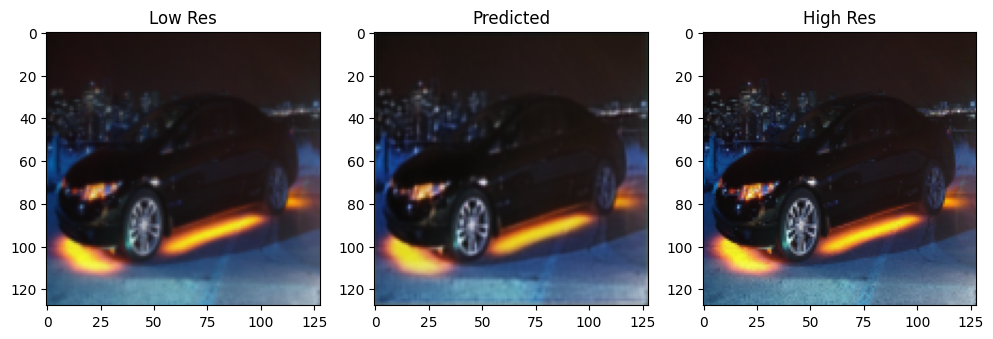

In [15]:
import matplotlib.pyplot as plt

idx = 0

low_img = X_val[idx]
high_img = y_val[idx]

pred_img = model.predict(low_img.reshape(1, SIZE, SIZE, 3))[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Low Res")
plt.imshow(low_img)

plt.subplot(1,3,2)
plt.title("Predicted")
plt.imshow(pred_img)

plt.subplot(1,3,3)
plt.title("High Res")
plt.imshow(high_img)

plt.show()